# Plots for the ECR data

### 'mol_id',  'exprank_group',  'exprank',  'rank_vina',  'rank_rf4',  'rank_nn2',  'E_vina, kcal/mol',  'E_rf4, kcal/mol',  'E_nn2, kcal/mol'

In [1]:
import os
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

# Data we have: **dockscore dataframe** + **ecr dataframe**

In [3]:
df_dock = pd.read_csv('binded_Mpro_sorted_by_vina.csv') # set a path to dockscore results (dockscore.csv)
df_ecr = pd.read_csv('ECR_results_binded.csv')  # set a path to ECR results (ECR.csv) 

workdir = os.getcwd() # default = current work directory                             !!!
dir_for_graphs = workdir + os.sep + 'graphs' # directory for graphs

In [4]:
def preprocessing(df):
    """ Function for getting standart input data.
        1) 'Filename of ligand' -> 'mol_id' 
        2) delete '_s'
        3) delete compounds with E_vina >= 0
        4) droping 'index' column """
    
    if 'Filename of ligand' in df.columns:
        df.rename(columns={'Filename of ligand':'mol_id'}, inplace=True)

    if df['mol_id'][0][-2:] == '_s':
        df['mol_id'] = [s[:-2] for s in df['mol_id']]
    
    df = df[df['E_vina, kcal/mol'] < 0]
    
    if 'index' in df.columns:
        df.drop('index', inplace=True, axis=1)
    return df

### Dockscore

In [5]:
df_dock = preprocessing(df_dock)
print(df_dock.shape)
df_dock.head(3)

(28439, 6)


,mol_id,"E_vina, kcal/mol","E_rf4, kcal/mol","Kd_rf4, uM","E_nn2, kcal/mol","Kd_nn2, uM"
0,src-selleckchem_lib-49_molid-5319_fragid-0,-10.7,-10.793950,0.024547,-9.412188,0.2313
1,src-selleckchem_lib-9_molid-2808_fragid-0,-10.5,-10.964156,0.018621,-8.220820,1.6000
2,src-zinc_lib-6_molid-ZINC000096006012_fragid-0,-10.4,-10.127306,0.072444,-9.588957,0.1736


### ECR

In [6]:
df_ecr = preprocessing(df_ecr)
print(df_ecr.shape)
df_ecr.head(3)

(187, 9)


,mol_id,exprank_group,exprank,rank_vina,rank_rf4,rank_nn2,"E_vina, kcal/mol","E_rf4, kcal/mol","E_nn2, kcal/mol"
0,src-drugbank_lib-1_molid-DB04868_fragid-0,1,0.271451,1,1,1,-9.3,-11.035076,-12.403436
1,src-zinc_lib-4_molid-ZINC000008101127_fragid-0,1,0.271451,1,1,1,-9.4,-11.418041,-16.343938
2,src-selleckchem_lib-9_molid-3173_fragid-0,2,0.262841,2,1,1,-9.1,-11.063444,-12.706801


# Auxiliary data

In [105]:
version = 'eng' # 'eng' or 'rus', switch version if needed    

names = {
    0:'E_vina, kcal/mol',
    1:'E_rf4, kcal/mol',
    2:'E_nn2, kcal/mol', 
    3:'exprank',
    4:'exprank_group'
}

magic_dict = {'E_vina, kcal/mol': r'$ΔG_{VINA}$, kcal/mol', 'E_rf4, kcal/mol': r'$ΔG_{RFScore4}$, kcal/mol', 'E_nn2, kcal/mol':'$ΔG_{NNScore2}$, kcal/mol'}
if version == 'rus':
    magic_dict = {'E_vina, kcal/mol': r'$ΔG_{VINA}$, ккал/моль', 'E_rf4, kcal/mol': r'$ΔG_{RFScore4}$, ккал/моль', 'E_nn2, kcal/mol':'$ΔG_{NNScore2}$, ккал/моль'}

colours = {0:'red', 1:'green', 2:'blue', 3:'black'}

if version == 'eng':
    ylabels = { 0: 'Number of compounds', 
               1: 'Fraction of compounds',
               2: 'Number of compounds, %' }
    
    xlabels = { 0: 'ΔG, kcal/mol - calculated by AutoDock Vina',
                1: 'ΔG, kcal/mol - calculated by RF-Score-4',
                2: 'ΔG, kcal/mol - calculated by NNScore-2.0',
                3: 'Exponential consensus rank',
                4: 'Exponential consensus rank group'}
else:
    ylabels = { 0: 'Количество соединений', 
               1: 'Доля соединений',
               2: 'Количество соединений, %' }

    xlabels = { 0: 'ΔG, ккал/моль - вычислено при помощи AutoDock Vina',
                1: 'ΔG, ккал/моль - вычислено при помощи RF-Score-4',
                2: 'ΔG, ккал/моль - вычислено при помощи NNScore-2.0',
                3: 'Экспоненциальный консенсусный ранг',
                4: 'Экспоненциальный консенсусный ранг. Группа'}

out_files_names = {  0: 'com_energy_vina_all_compounds_plot',
                     1: 'com_energy_rf4_all_compounds_plot',
                     2: 'com_energy_nn2_all_compounds_plot',
                     3: 'com_exprank_ecr_plot',
                     4: 'hist_energy_vina_all_compounds_plot',
                     5: 'hist_energy_rf4_all_compounds_plot',
                     6: 'hist_energy_nn2_all_compounds_plot',
                     7: 'hist_exprank_ecr_plot',
                     8: 'three_functions_hists'
                  }
if version == 'eng':
    out_files = [f + '_eng' for f in out_files_names.values()]
else:     
    out_files = [f + '_rus' for f in out_files_names.values()]

# Cumulative graph

In [39]:
def to_percent(x, total_x): # x >= 0
    return 100.*x / total_x

def res_y_values_com_plot(data, x_values):
    """ Cumulative distribution function. Strange implementation.
        O(n) since the data is already sorted 
        
        !!! result in percents
        
        x_values is sorted ascending
        data is sorted ascending
    """
    total_data_len = len(data)      
    d = {}

    for i in range(len(data)): # O(n)
        cur_num = data[i]

        if cur_num in d:
            d[cur_num] += 1
        else:
            if i>0:
                d[cur_num] = d[data[i-1]] + 1
            else: d[cur_num] = 1
    
    d_val = list(d.keys())
    i = 0
    res = []
    for c_x in x_values: # O(n_val + n)
        if c_x < d_val[0]:
            res.append(0)
        else:
            while i < len(d_val) and c_x >= d_val[i]: # d_val < c_x or the index is out of range
                i += 1
            res.append(d[d_val[i-1]])
            
    return [to_percent(num, total_data_len) for num in res]

In [40]:
def draw_energy_com_plot(data, xlabel, num_x_points, line_color, out_file_name, ylabel = ylabels[2],):
    """ data: DF Series of energy values
        num_x_points: number of gaps + 1
        
        !!! in percents
        """
    data = list(data)
    # ascending
    data.sort() # O(nlog(n)) where n is an amount of compounds
    data_min, data_max = min(data), max(data)
    
    k = 10                           # number of gaps            !!! changeable
    d = (data_max - data_min) / k

    x_values = np.linspace(data_min, data_max, num_x_points) 
    y_values = res_y_values_com_plot(data, x_values) 
        
    fig = plt.figure(figsize = (23, 10))
    ax = fig.add_axes([0.06,0.10,0.90,0.85]) 
    
    ax.plot(x_values, y_values, linewidth=2.5, color = line_color)
        
    y_ticks = [i*10 for i in range(0, 11)]
    x_ticks = [ round((data_min + i*d), 3) for i in range(k+1)]
    
    ax.set_yticks(y_ticks)
    ax.set_xticks(x_ticks)
    ax.tick_params(labelsize=23)
    ax.set_xlabel(xlabel, fontsize=30, color='black', labelpad = 17)
    ax.set_ylabel(ylabel, fontsize=30, color='black', labelpad = 17)

    plt.savefig(dir_for_graphs + os.sep + out_file_name + '.png', facecolor="#ffffff", edgecolor='none')
    plt.show()

In [43]:
#draw_energy_com_plot(df_dock[names[0]], xlabels[0], ylabel, 300, colours[0], out_files[0])

# Histograms

# Single histogram 

In [84]:
def draw_freq_destrib_hist(data, xlabel, ylabel, out_file_name, exprank=False, density = False):
    """ data: DataFrame Series (or list) after ranking
        density: if True that Oy - in fractions of the whole number of compounds """    
    diff_val_num = len(set(data)) # get unique

    if exprank:
        bin_num = diff_val_num
    else:
        bin_num = 40
        
    fig = plt.figure(figsize = (23, 10))
    ax = fig.add_axes([0.06,0.10,0.90,0.85])
    if exprank:
        ax.hist(data,range=(1, bin_num + 1), rwidth=0.85, bins=bin_num, edgecolor='black', density=density, align='left') # density = 0/1
        ax.set_xticks([i for i in range(1, max(data), 3)])
    else:
        ax.hist(data, rwidth=0.85, edgecolor='black', density=density, bins = bin_num) #
    ax.set_xlabel(xlabel, fontsize=30, labelpad = 17, color='black')
    
    ax.set_ylabel(ylabel, fontsize=30, labelpad = 17, color='black')
    ax.tick_params(labelsize=20)

    plt.savefig(dir_for_graphs + os.sep + out_file_name + '.png', facecolor="#ffffff", edgecolor='none')
    plt.show()    

In [86]:
#draw_freq_destrib_hist(df_ecr[names[4]], xlabels[4], ylabels[0], out_files[3], exprank=True, density = False)

# Three histograms in row

In [103]:
def three_hist_in_row(data,  ylabel, out_file_name, max_y = 5500):
    """ data: DataFrame with 3 columns (vina, NNScore, RFScore)
        max_y: !!! it's important to find a good max_y value in other hand the horizontal lines will be at different levels"""
    
    fig, axs = plt.subplots(1, 3, figsize=(25, 7))
    fig.subplots_adjust(left = 0.05, right=0.98, top=0.98, bottom=0.01, wspace=0.2, hspace=0.3)
    num_bins = 20

    # only needed if we set xlabels by hands
    # num_x_points = 5 
    # data_min = {column : data[column].min() for column in data.columns.values.tolist()}
    # data_max = {column : data[column].max() for column in data.columns.values.tolist()}
    # x_values = [np.linspace(data_min[column], data_max[column], num_x_points) for column in data.columns.values.tolist()]

    count = 0
    
    for ax in axs:
        ax.set_ylim(top=max_y) 
        
        if count==1:
            ax.set_yticklabels([])
            #ax.set_xticks(x_values[1])
        elif count==2:
            ax.set_yticklabels([])
            #ax.set_xticks([-14,-11,-8,-5,-2,1])#[-15,-12,-9,-6,-3,0]
        
        ax.hist(data[data.columns[count]], rwidth=0.85, bins=num_bins, edgecolor='black', density = False)
        
        ax.tick_params(labelsize=30)
        ax.set_xlabel(magic_dict[data.columns[count]], fontsize=37, color='black', labelpad = 17)
        
        if count < 1:
            ax.set_ylabel(ylabel, fontsize=37, color='black', labelpad = 15)
        count += 1
    
    fig.tight_layout()
    plt.savefig(dir_for_graphs + os.sep + out_file_name, facecolor="#ffffff", edgecolor='none', bbox_inches = 'tight')
    plt.show()

# Main graphs

# ECR group histogram

In [94]:
# draw_freq_destrib_hist(df_ecr[names[4]], xlabels[4], ylabels[0], out_files[3], exprank=True, density = False)

# Cumulative plots

In [99]:
# single
#draw_energy_com_plot(df_dock[names[0]], xlabels[0], ylabels[2], 300, colours[2], out_files[0])

In [100]:
# three in one command
#for i in range(3):
#    if i == 3:
#        draw_energy_com_plot(df_dock[names[i]], xlabels[i], ylabels[2], 300, colours[i], out_files[i], True)
#    else:
#        draw_energy_com_plot(df_dock[names[i]], xlabels[i], ylabels[2], 300, colours[i], out_files[i])

# Three histograms in row

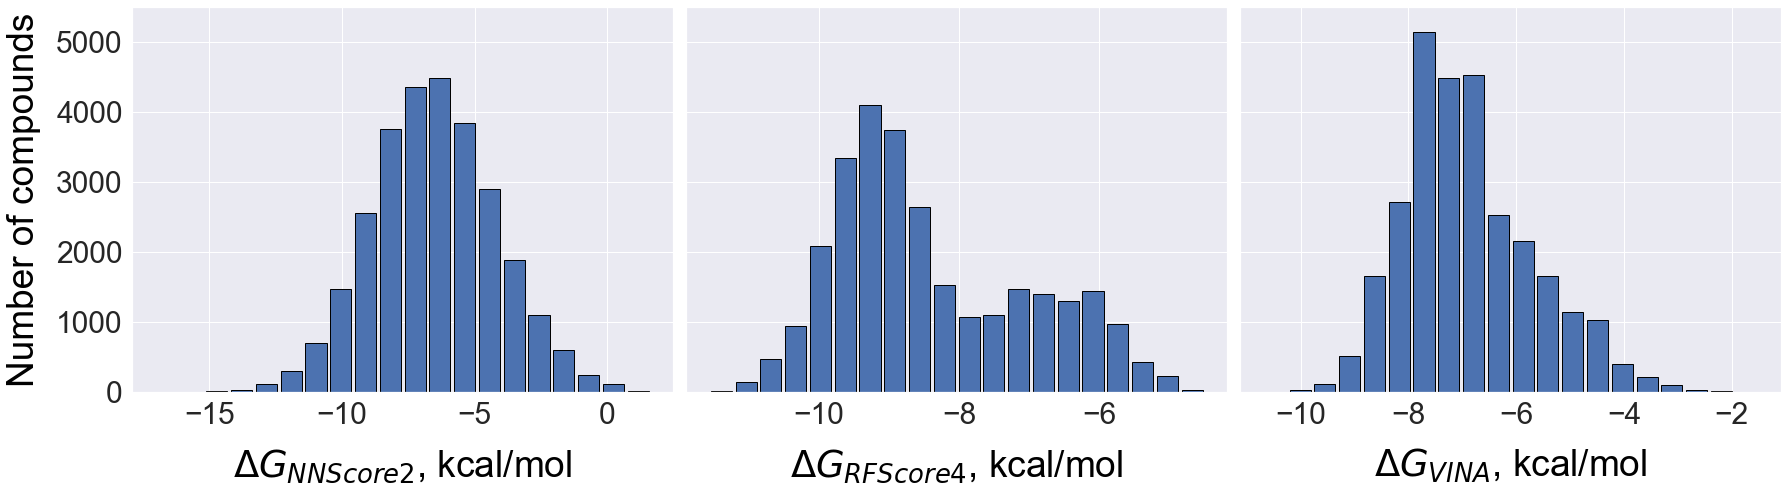

In [106]:
df_new = df_dock[[names[0], names[1], names[2]]]
three_hist_in_row(df_new, ylabels[0], out_files[8]) 

In [102]:
# the end